# Retail Sales - EDA and Data Cleaning
Dataset: retail_sales_dataset.csv (Kaggle)

## Phase 1: Load and Inspect Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('retail_sales_dataset.csv')

In [2]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:
print(df.shape)
print(df.columns)
print(df.dtypes)

(1000, 9)
Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='str')
Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object


In [4]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


## Phase 2: Data Cleaning

In [5]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['Date'] = pd.to_datetime(df['Date'])
df['Date'].dtype

dtype('<M8[us]')

## Phase 3: Outlier Detection and Treatment

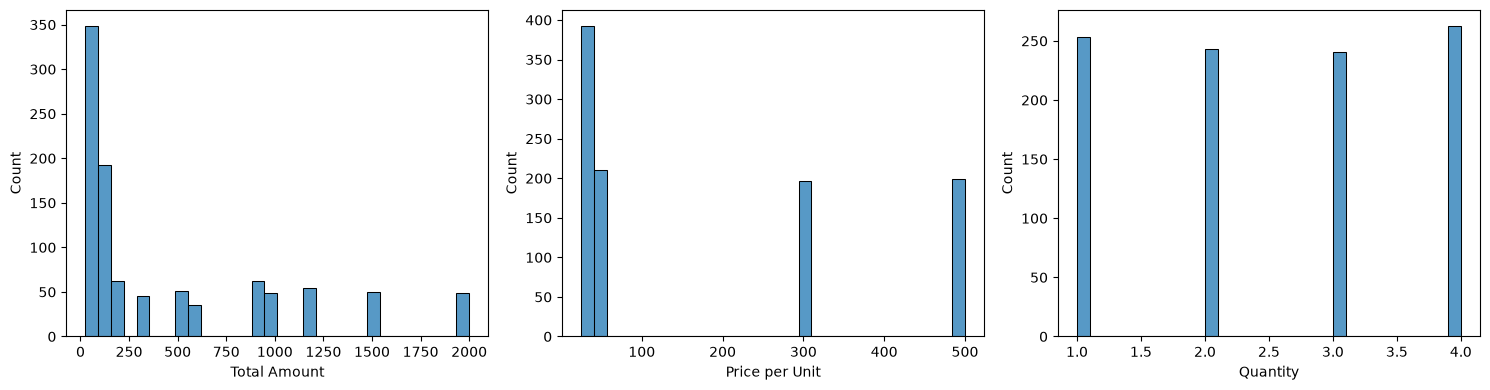

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['Total Amount'], bins=30, ax=axes[0])
sns.histplot(df['Price per Unit'], bins=30, ax=axes[1])
sns.histplot(df['Quantity'], bins=30, ax=axes[2])
plt.tight_layout()
plt.show()

In [9]:
Q1 = df.groupby('Product Category')['Total Amount'].transform(lambda x: x.quantile(0.25))
Q3 = df.groupby('Product Category')['Total Amount'].transform(lambda x: x.quantile(0.75))
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Total Amount'] < lower) | (df['Total Amount'] > upper)]
outliers

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
15,16,2023-02-17,CUST016,Male,19,Clothing,3,500,1500
77,78,2023-07-01,CUST078,Female,47,Clothing,3,500,1500
111,112,2023-12-02,CUST112,Male,37,Clothing,3,500,1500
114,115,2023-11-26,CUST115,Male,51,Clothing,3,500,1500
123,124,2023-10-27,CUST124,Male,33,Clothing,4,500,2000
165,166,2023-04-02,CUST166,Male,34,Clothing,4,500,2000
211,212,2023-06-09,CUST212,Male,21,Clothing,3,500,1500
214,215,2023-11-29,CUST215,Male,58,Clothing,3,500,1500
252,253,2023-08-31,CUST253,Female,53,Clothing,4,500,2000
268,269,2023-02-01,CUST269,Male,25,Clothing,4,500,2000


In [10]:
print(len(outliers))
outliers['Product Category'].value_counts()

32


Product Category
Clothing    32
Name: count, dtype: int64

In [11]:
df[df['Product Category'] == 'Clothing']['Price per Unit'].describe()

count    351.000000
mean     174.287749
std      186.017065
min       25.000000
25%       30.000000
50%       50.000000
75%      300.000000
max      500.000000
Name: Price per Unit, dtype: float64

In [12]:
# decide: keep, cap, or flag outliers - and explain why
# Decision: 32 statistical outliers found, all in the Clothing category.
# These come from items priced at Rs.500/unit (the max price within Clothing, confirmed via describe())
# combined with higher quantities (3-4 units per transaction).
# Not data errors - Rs.500 is a genuine existing price point in this category, not an impossible value.
# Decision: Retained in dataset - represent legitimate premium clothing purchases, not data quality issues.

print(f"{len(outliers)} statistical outliers found, all within Clothing category.")
print("Decision: Retained - reflect genuine premium-priced purchases, not data errors.")

32 statistical outliers found, all within Clothing category.
Decision: Retained - reflect genuine premium-priced purchases, not data errors.


## Data Quality Report

**Dataset:** retail_sales_dataset.csv (1000 rows, 9 columns)

**Missing Values:** 0 missing values found across all columns (0%)

**Duplicate Rows:** 0 duplicate rows found (0%)

**Data Type Transformations:** 
- Converted 'Date' column from string to datetime format

**Outliers:**
- 32 rows (3.2% of dataset) flagged as statistical outliers via IQR method, applied per Product Category
- All 32 outliers found in the Clothing category, driven by items priced at Rs.500/unit (the max price point within that category) combined with higher quantities (3-4 units)
- Decision: Retained in dataset — these represent genuine premium-priced purchases, not data entry errors or corrupted values (no negative numbers, no impossible values found)

**Overall Assessment:** Dataset was clean upon import with no structural issues. Only transformation needed was date type correction.

## Phase 4: Summary Statistics and Visualizations

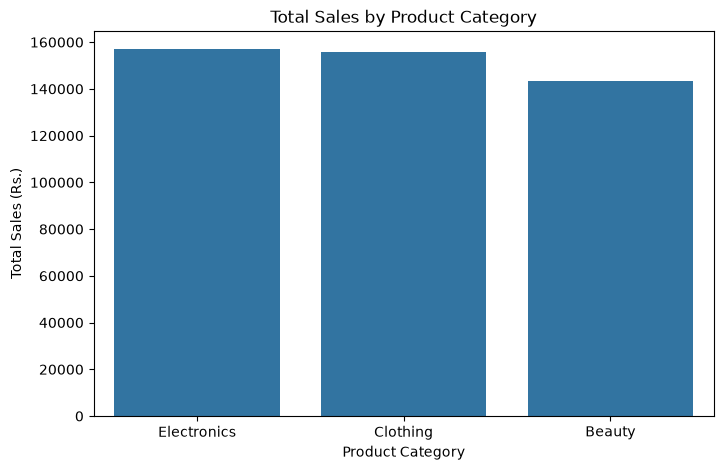

In [13]:
category_sales = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=category_sales.index, y=category_sales.values)
plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales (Rs.)')
plt.show()

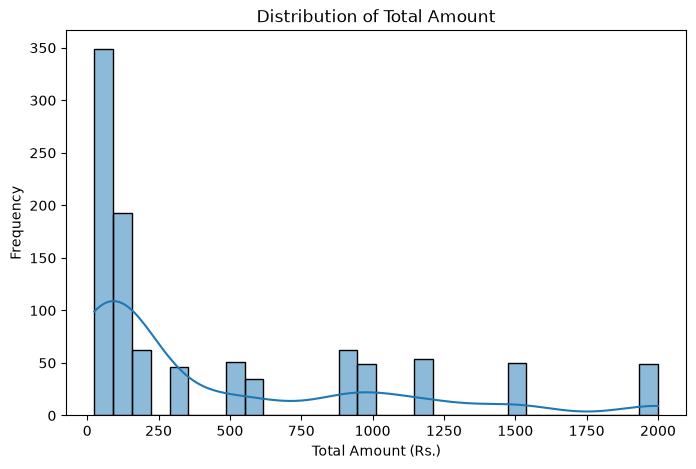

In [14]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Total Amount'], bins=30, kde=True)
plt.title('Distribution of Total Amount')
plt.xlabel('Total Amount (Rs.)')
plt.ylabel('Frequency')
plt.show()

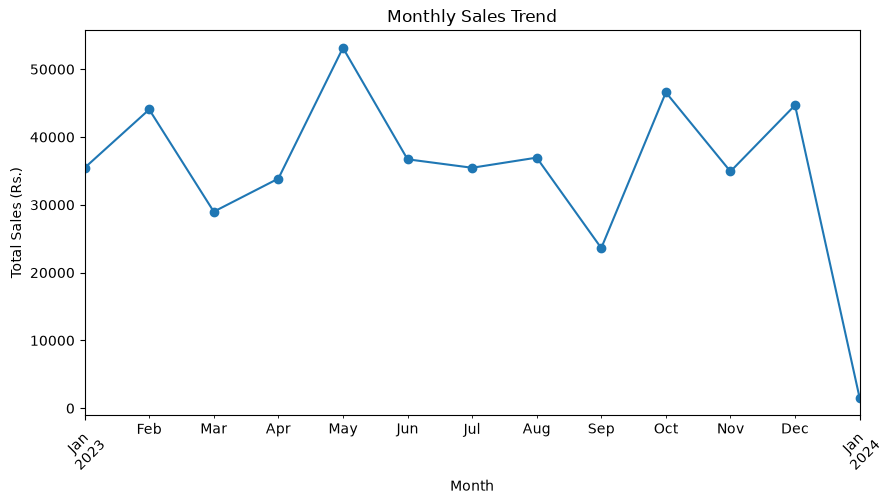

In [15]:
df['Month'] = df['Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Total Amount'].sum()

plt.figure(figsize=(10, 5))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales (Rs.)')
plt.xticks(rotation=45)
plt.show()

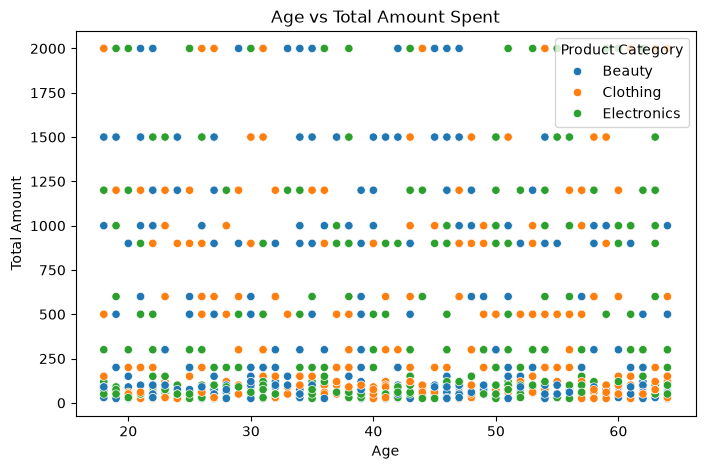

In [16]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Age', y='Total Amount', hue='Product Category', data=df)
plt.title('Age vs Total Amount Spent')

plt.show()

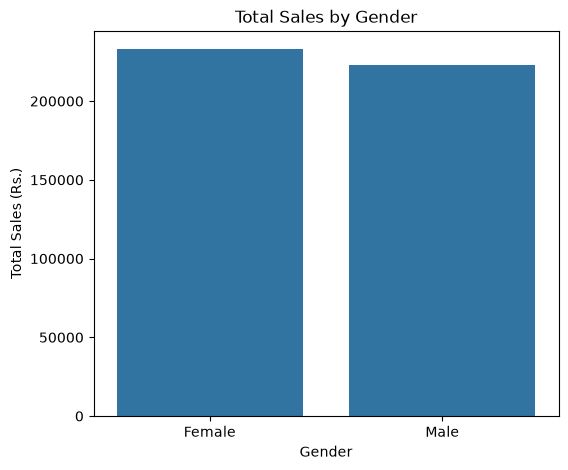

In [17]:
gender_sales = df.groupby('Gender')['Total Amount'].sum()

plt.figure(figsize=(6, 5))
sns.barplot(x=gender_sales.index, y=gender_sales.values)
plt.title('Total Sales by Gender')
plt.ylabel('Total Sales (Rs.)')
plt.show()

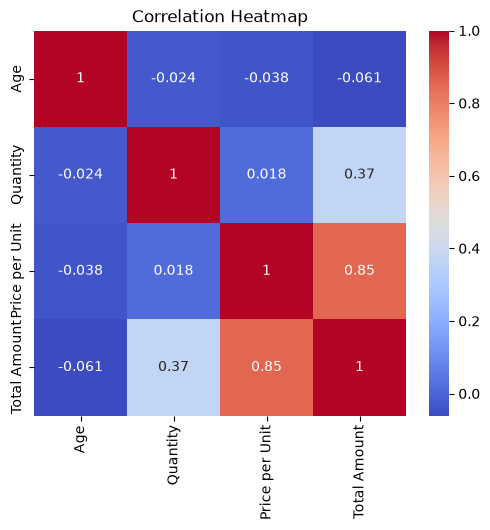

In [18]:
numeric_cols = df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']]

plt.figure(figsize=(6, 5))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Business Insights
- Electronics and Clothing drive the most revenue, Beauty lags behind — worth checking if Beauty is underpriced or under-marketed
- Sales show clear monthly seasonality with peaks in May and October — useful for planning inventory/promotions around these months
- Spending is consistent across gender and age groups — no single demographic dominates, suggesting broad appeal rather than a niche customer base
- Total Amount is driven mainly by item price, not quantity purchased (0.85 vs 0.37 correlation) — customers aren't bulk-buying, they're buying higher-priced individual items